In [1]:
import pandas as pd


df = pd.read_csv('forecasting-dataset.csv')


# Seven Questions to ask before working on the data Must #

In [2]:
#How big is the data

df.shape


(69353, 48)

In [4]:
#How does the data look like

df.head()

df.sample(5)


,postcode,Day_of_Week,Date,Branch Name,Total Sale,outercode,population,households,avg_household_income,unemployment_rate,...,is_covid_lockdown,Inferred_Brand,Days_Since_Open,rateable_value,distance_to_nearest_station_mi,distance_to_mcdonalds_kfc_mi,distance_to_mosque_mi,distance_to_university_mi,workplace_to_resident_ratio,ethnic_diversity_index
17627,E1 6RL,Monday,9/10/2012,pepes piri piri brick lane,870.76,E1,562,206,66032.0,0.0261,...,0,Pepe's,587,3627.0,0.176,0.255581,0.024143,0.277853,0.961,0.5831
20827,HA1 2TB,Tuesday,3/29/2011,pepes piri piri harrow,1729.38,HA1,242,96,75019.0,0.0361,...,0,Pepe's,137,5240.0,0.058,0.253911,0.417414,0.554654,0.495,0.6762
68591,WV1 1TQ,Tuesday,5/30/2023,rio's piri piri wolverhampton,714.81,WV1,345,168,36481.0,0.0860,...,0,Rio's,74,8354.0,0.201,0.052655,0.729161,0.172899,0.915,0.6348
57268,B10 0UT,Wednesday,7/17/2024,rio's piri piri small heath,1150.20,B10,592,162,39905.0,0.0622,...,0,Rio's,425,1870.0,0.421,0.643345,0.164160,1.507982,0.265,0.3993
62848,WA1 2RU,Sunday,10/23/2022,rio's piri piri warrington,340.87,WA1,186,139,40790.0,0.0324,...,0,Rio's,177,14284.0,0.024,0.146770,1.150380,2.690382,1.136,0.2559


In [5]:
#3.What is the data type of each column

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 69353 entries, 0 to 69352
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   postcode                        69353 non-null  str    
 1   Day_of_Week                     69353 non-null  str    
 2   Date                            69353 non-null  str    
 3   Branch Name                     69353 non-null  str    
 4   Total Sale                      67699 non-null  float64
 5   outercode                       69353 non-null  str    
 6   population                      69353 non-null  int64  
 7   households                      69353 non-null  int64  
 8   avg_household_income            69353 non-null  float64
 9   unemployment_rate               69353 non-null  float64
 10  working                         69353 non-null  float64
 11  unemployed                      69353 non-null  float64
 12  ab                              69353 non-n

In [6]:
#are there any missing values in the data

df.isnull().sum()


postcode                              0
Day_of_Week                           0
Date                                  0
Branch Name                           0
Total Sale                         1654
outercode                             0
population                            0
households                            0
avg_household_income                  0
unemployment_rate                     0
working                               0
unemployed                            0
ab                                    0
c1/c2                                 0
de                                    0
white                                 0
non-white                             0
Distance_to_Nearest_Station           0
Nearby_Station_Count                  0
Nearest_Station_Type                  0
Transport_Accessibility_Score         0
Dataset                               0
Brand Name                        69353
is_data_reliable                      0
Total_Sale_Normalized              1654


In [7]:
#How does data look mathematically

df.describe()


,Total Sale,population,households,avg_household_income,unemployment_rate,working,unemployed,ab,c1/c2,de,...,is_Boxing_Day,is_covid_lockdown,Days_Since_Open,rateable_value,distance_to_nearest_station_mi,distance_to_mcdonalds_kfc_mi,distance_to_mosque_mi,distance_to_university_mi,workplace_to_resident_ratio,ethnic_diversity_index
count,67699.000000,69353.000000,69353.000000,69353.000000,69353.000000,69353.000000,69353.000000,69353.000000,69353.000000,69353.000000,...,69353.000000,69353.000000,69353.000000,69353.000000,69353.000000,69353.000000,69353.000000,69353.000000,69353.000000,69353.000000
mean,768.324193,396.370871,166.671435,53999.874059,0.048406,0.951876,0.048124,0.264492,0.306295,0.429206,...,0.002408,0.041902,637.398310,3719.532700,0.257437,0.388023,0.815095,2.474527,2.539551,0.496770
std,513.361240,197.339385,102.221163,16752.628938,0.035944,0.034988,0.034988,0.152637,0.101606,0.165850,...,0.049012,0.200366,452.317644,5276.542267,0.424517,0.341901,1.340813,3.790201,32.589821,0.195979
min,0.000000,142.000000,47.000000,13716.981200,0.005200,0.580300,0.005200,0.013800,0.007800,0.105800,...,0.000000,0.000000,0.000000,122.850000,0.006000,0.021828,0.024143,0.061824,0.212000,0.016000
25%,387.430000,285.000000,115.000000,41679.000000,0.027000,0.939700,0.027000,0.157700,0.233100,0.329000,...,0.000000,0.000000,256.000000,978.000000,0.022000,0.092598,0.257836,0.504684,0.365000,0.365700
50%,699.160000,352.000000,154.000000,51229.000000,0.042900,0.957100,0.042900,0.245400,0.317200,0.398400,...,0.000000,0.000000,559.000000,2087.000000,0.042026,0.292814,0.406243,1.280426,0.495000,0.568000
75%,1035.515000,470.000000,189.000000,66032.000000,0.060300,0.973000,0.060300,0.361600,0.375500,0.540400,...,0.000000,0.000000,958.000000,3767.000000,0.329000,0.612232,0.957075,2.865256,0.961000,0.660400
max,10465.190000,1160.000000,715.000000,96418.000000,0.430000,0.994800,0.419700,0.687800,0.515100,0.978400,...,1.000000,1.000000,2007.000000,33416.000000,1.591000,2.277612,19.979787,24.597410,856.098000,0.763600


In [8]:
#Are there duplicated values in the data 

df.duplicated().sum()


np.int64(0)

In [12]:
# How is the correlation between the columns

df.corr(numeric_only=True)["Total Sale"]


Total Sale                        1.000000
population                       -0.088170
households                       -0.107721
avg_household_income              0.085393
unemployment_rate                -0.003181
working                          -0.002667
unemployed                        0.002667
ab                               -0.110027
c1/c2                            -0.056504
de                                0.135736
white                            -0.168142
non-white                         0.168142
Distance_to_Nearest_Station       0.083685
Nearby_Station_Count              0.036160
Transport_Accessibility_Score    -0.076063
Brand Name                             NaN
is_data_reliable                  0.206843
Total_Sale_Normalized             0.949478
is_logistics_strike              -0.070268
is_delivery_crackdown            -0.001027
is_payday_window                  0.017820
is_NYE                            0.008550
is_NYD                           -0.010831
is_Christma

# 2.Exploratory Data Analysis (EDA)#

## a. Univarient

In [1]:
import pandas as pd
import seaborn  as sns


df = pd.read_csv('forecasting-dataset.csv')


### i. Categorical 

In [2]:
# Keep columns that have more than one unique value
df_cleaned = df.loc[:, df.nunique() > 1]


In [3]:
df_cleaned


,postcode,Day_of_Week,Date,Branch Name,Total Sale,outercode,population,households,avg_household_income,unemployment_rate,...,is_covid_lockdown,Inferred_Brand,Days_Since_Open,rateable_value,distance_to_nearest_station_mi,distance_to_mcdonalds_kfc_mi,distance_to_mosque_mi,distance_to_university_mi,workplace_to_resident_ratio,ethnic_diversity_index
0,KA21 5DT,Saturday,2/1/2025,galos peri peri hamilton,347.53,KA21,686,548,13716.9812,0.430,...,0,Galos,0,1365.0,0.241441,2.277612,19.979787,14.023843,120.827,0.0160
1,KA21 5DT,Sunday,2/2/2025,galos peri peri hamilton,119.68,KA21,686,548,13716.9812,0.430,...,0,Galos,1,1365.0,0.241441,2.277612,19.979787,14.023843,120.827,0.0160
2,KA21 5DT,Monday,2/3/2025,galos peri peri hamilton,136.20,KA21,686,548,13716.9812,0.430,...,0,Galos,2,1365.0,0.241441,2.277612,19.979787,14.023843,120.827,0.0160
3,KA21 5DT,Tuesday,2/4/2025,galos peri peri hamilton,92.67,KA21,686,548,13716.9812,0.430,...,0,Galos,3,1365.0,0.241441,2.277612,19.979787,14.023843,120.827,0.0160
4,KA21 5DT,Wednesday,2/5/2025,galos peri peri hamilton,124.94,KA21,686,548,13716.9812,0.430,...,0,Galos,4,1365.0,0.241441,2.277612,19.979787,14.023843,120.827,0.0160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69348,WV1 1TQ,Thursday,6/26/2025,rio's piri piri wolverhampton,794.19,WV1,345,168,36481.0000,0.086,...,0,Rio's,832,8354.0,0.201000,0.052655,0.729161,0.172899,0.915,0.6348
69349,WV1 1TQ,Friday,6/27/2025,rio's piri piri wolverhampton,582.61,WV1,345,168,36481.0000,0.086,...,0,Rio's,833,8354.0,0.201000,0.052655,0.729161,0.172899,0.915,0.6348
69350,WV1 1TQ,Saturday,6/28/2025,rio's piri piri wolverhampton,458.56,WV1,345,168,36481.0000,0.086,...,0,Rio's,834,8354.0,0.201000,0.052655,0.729161,0.172899,0.915,0.6348
69351,WV1 1TQ,Sunday,6/29/2025,rio's piri piri wolverhampton,174.68,WV1,345,168,36481.0000,0.086,...,0,Rio's,835,8354.0,0.201000,0.052655,0.729161,0.172899,0.915,0.6348


In [4]:
df_cleaned.shape
#frequency of the numbers I want


(69353, 46)

Day_of_Week
Saturday     9948
Friday       9944
Monday       9910
Sunday       9905
Thursday     9901
Wednesday    9875
Tuesday      9870
Name: count, dtype: int64

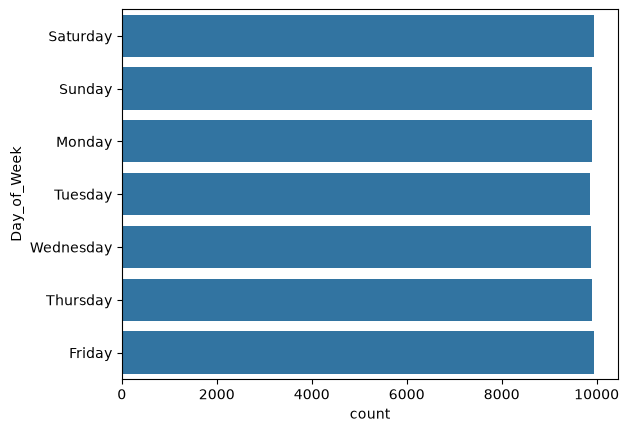

In [5]:
sns.countplot(df_cleaned['Day_of_Week'])

df_cleaned['Day_of_Week'].value_counts()


### ii.Pie Chart

<Axes: >

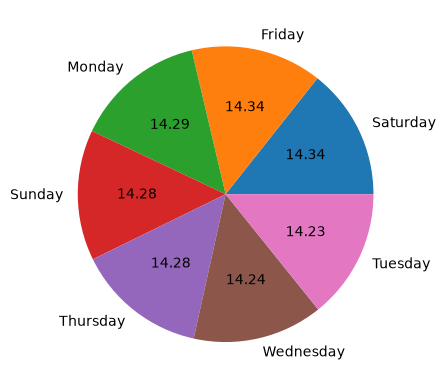

In [6]:

df_cleaned['Day_of_Week'].value_counts().plot(kind='pie',autopct='%.2f')


## 2.Numerical Data 

### i. Histogram

In [8]:
df_cleaned.sample(5)


,postcode,Day_of_Week,Date,Branch Name,Total Sale,outercode,population,households,avg_household_income,unemployment_rate,...,is_covid_lockdown,Inferred_Brand,Days_Since_Open,rateable_value,distance_to_nearest_station_mi,distance_to_mcdonalds_kfc_mi,distance_to_mosque_mi,distance_to_university_mi,workplace_to_resident_ratio,ethnic_diversity_index
37229,CR0 1YB,Tuesday,11/9/2021,rio's piri piri croydon,1143.85,CR0,231,131,74533.0,0.0435,...,0,Rio's,312,4718.0,0.084,0.079408,0.806725,4.932937,1.470,0.6980
27162,HA9 7AB,Saturday,8/18/2012,pepes piri piri wembley,1317.99,HA9,488,172,59923.0,0.0424,...,0,Pepe's,626,2051.0,0.016,0.035443,0.257836,2.075119,0.343,0.5301
64238,WD24 4FT,Thursday,2/17/2022,rio's piri piri watford,385.26,WD24,515,198,59251.0,0.0123,...,0,Rio's,412,978.0,0.065,0.021828,0.957075,4.287137,0.457,0.6154
67634,DT4 8NY,Saturday,1/28/2023,rio's piri piri weymouth,311.04,DT4,389,218,39524.0,0.0384,...,0,Rio's,757,6785.0,0.031,0.339855,0.211475,24.597410,0.594,0.1902
23502,KT1 1SF,Sunday,9/1/2013,pepes piri piri kingston,598.94,KT1,340,119,84290.0,0.0296,...,0,Pepe's,123,33416.0,0.028,0.052548,0.320078,0.504470,1.068,0.5853


(array([69186.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,   167.]),
 array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 

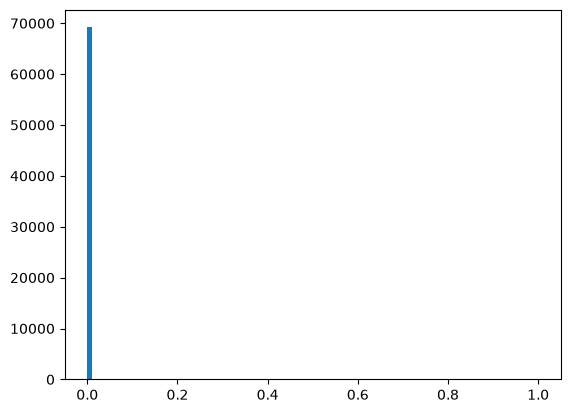

In [17]:
from matplotlib import pyplot as plt
plt.hist(df_cleaned['is_Boxing_Day'], bins=100)



### ii Displot

C:\Users\farma\AppData\Local\Temp\ipykernel_2248\2634422178.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_cleaned["is_Boxing_Day"])


<Axes: xlabel='is_Boxing_Day', ylabel='Density'>

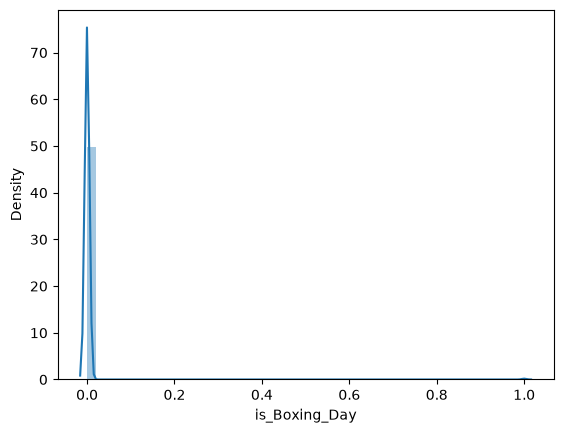

In [20]:
sns.distplot(df_cleaned["is_Boxing_Day"])


C:\Users\farma\AppData\Local\Temp\ipykernel_2248\46429069.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_cleaned["Total_Sale_Normalized"])


<Axes: xlabel='Total_Sale_Normalized', ylabel='Density'>

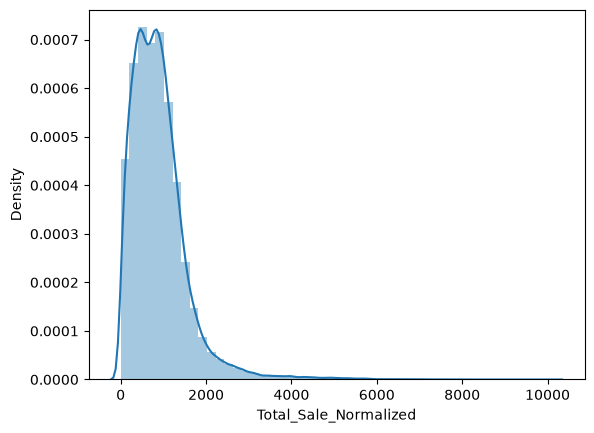

In [24]:
sns.distplot(df_cleaned["Total_Sale_Normalized"])


### iii. Boxplot


<Axes: ylabel='Total_Sale_Normalized'>

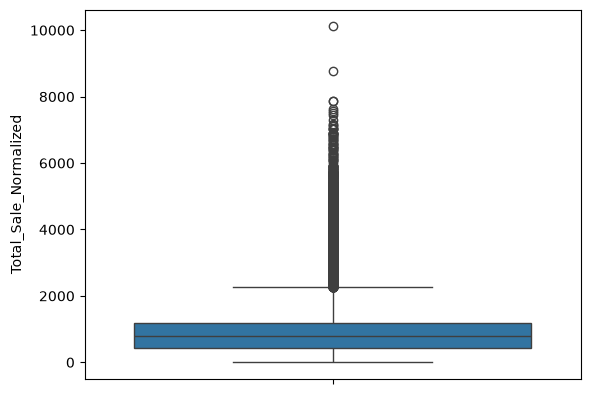

In [27]:
sns.boxplot(df_cleaned["Total_Sale_Normalized"])


In [ ]:
df_cleaned['Total Sale'].mean()


np.float64(768.3241928241185)

In [31]:
df_cleaned["Total Sale"].skew()


np.float64(1.5340368686293546)